# 03 Run New Models Complete

This single notebook does the full new-model workflow:

1. Loads the prepared panel data.
2. Runs the Naive / Random Walk baseline.
3. Runs or loads N-BEATS and PatchTST results.
4. Runs or loads Chronos zero-shot results.
5. Runs or loads Kronos zero-shot results.
6. Merges all predictions.
7. Creates summaries, cross-sectional RankIC, and plots.

Use this instead of running a separate results-loader notebook.

In [17]:
from pathlib import Path
import sys
import warnings

# Works whether the notebook is inside the project root or inside a notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)

warnings.filterwarnings("ignore", message="val_check_steps is greater than max_steps.*")

Project root: c:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project
Python: c:\Users\user\AppData\Local\Programs\Python\Python311\python.exe


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from src.config import (
    DATA_PROCESSED_DIR,
    RESULTS_DIR,
    PLOTS_DIR,
    HORIZONS,
    INPUT_SIZE,
    TEST_STEP,
    MAX_TEST_DATES,
    MAX_STEPS,
    FREQ,
    MIN_ASSETS_FOR_RANKIC,
    RANDOM_SEED,
    CHRONOS_MODEL_ID,
    KRONOS_MODEL_ID,
    KRONOS_TOKENIZER_ID,
    KRONOS_LOCAL_REPO,
)

from src.new_models import (
    BenchmarkConfig,
    run_neuralforecast_models,
    run_chronos_zero_shot,
    run_kronos_zero_shot,
    run_naive_baseline,
)

from src.data_utils import load_prepared_panel

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Results dir:", RESULTS_DIR)
print("Plots dir:", PLOTS_DIR)

Results dir: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models
Plots dir: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots


In [19]:
# Main run controls
# Set FORCE_RERUN_* = False to reuse existing CSV files and avoid retraining.

RUN_NEURAL_MODELS = True
RUN_CHRONOS = True
RUN_KRONOS = True

FORCE_RERUN_NEURAL = True
FORCE_RERUN_CHRONOS = True
FORCE_RERUN_KRONOS = True

# Keep this True while setting up Kronos. It attempts Kronos, but still lets the notebook continue
# if the local Kronos repo/dependencies are not ready yet.
ALLOW_CONTINUE_IF_KRONOS_FAILS = True

NEURAL_MODELS_TO_RUN = ["NBEATS", "PatchTST"]

# For faster debugging, uncomment this smaller config.
# OVERRIDE_CONFIG = dict(horizons=[1], input_size=60, test_step=63, max_test_dates=3, max_steps=10)

OVERRIDE_CONFIG = None

In [20]:
panel = load_prepared_panel(DATA_PROCESSED_DIR)
panel = panel.sort_values(["Ticker", "Date"]).reset_index(drop=True)

if OVERRIDE_CONFIG:
    config = BenchmarkConfig(
        horizons=OVERRIDE_CONFIG.get("horizons", HORIZONS),
        input_size=OVERRIDE_CONFIG.get("input_size", INPUT_SIZE),
        test_step=OVERRIDE_CONFIG.get("test_step", TEST_STEP),
        max_test_dates=OVERRIDE_CONFIG.get("max_test_dates", MAX_TEST_DATES),
        max_steps=OVERRIDE_CONFIG.get("max_steps", MAX_STEPS),
        freq=FREQ,
        random_seed=RANDOM_SEED,
    )
else:
    config = BenchmarkConfig(
        horizons=HORIZONS,
        input_size=INPUT_SIZE,
        test_step=TEST_STEP,
        max_test_dates=MAX_TEST_DATES,
        max_steps=MAX_STEPS,
        freq=FREQ,
        random_seed=RANDOM_SEED,
    )

print("Panel shape:", panel.shape)
print("Tickers:", panel["Ticker"].nunique(), sorted(panel["Ticker"].unique())[:20])
print("Date range:", panel["Date"].min(), "to", panel["Date"].max())
print("Config:", config)
display(panel.head())

Panel shape: (95400, 11)
Tickers: 50 ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AMD', 'AMZN', 'AVGO', 'BAC', 'BLK', 'CAT', 'COST', 'CRM', 'CSCO', 'CVX', 'DIS', 'GE', 'GOOGL', 'GS', 'HD']
Date range: 2019-01-02 00:00:00 to 2026-04-24 00:00:00
Config: BenchmarkConfig(horizons=[1, 5], input_size=128, test_step=21, max_test_dates=18, max_steps=40, freq='B', random_seed=42)


,Date,Ticker,open,high,low,close,adj_close,volume,return_1d,log_return_1d,amount
0,2019-01-02,AAPL,38.722500,39.712502,38.557499,39.480000,37.503727,148158800.0,NaN,NaN,5.849309e+09
1,2019-01-03,AAPL,35.994999,36.430000,35.500000,35.547501,33.768078,365248800.0,-0.099607,-0.104924,1.298368e+10
2,2019-01-04,AAPL,36.132500,37.137501,35.950001,37.064999,35.209618,234428400.0,0.042689,0.041803,8.689088e+09
3,2019-01-07,AAPL,37.174999,37.207500,36.474998,36.982498,35.131241,219111200.0,-0.002226,-0.002228,8.103280e+09
4,2019-01-08,AAPL,37.389999,37.955002,37.130001,37.687500,35.800953,164101200.0,0.019063,0.018884,6.184564e+09


## Helper functions for summaries, RankIC, and plots

These are included directly in the notebook so the file can still summarize results even if `src.evaluation` has version issues.

In [21]:
def summarize_predictions_local(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    required = ["Model", "Horizon", "y_true", "y_pred"]
    missing = [c for c in required if c not in predictions.columns]
    if missing:
        raise ValueError(f"Missing columns for summary: {missing}")

    for (model, horizon), g in predictions.groupby(["Model", "Horizon"]):
        g = g.dropna(subset=["y_true", "y_pred"])
        if g.empty:
            continue
        err = g["y_true"].to_numpy() - g["y_pred"].to_numpy()
        rows.append({
            "Model": model,
            "Horizon": int(horizon),
            "N": int(len(g)),
            "MAE": float(np.mean(np.abs(err))),
            "RMSE": float(np.sqrt(np.mean(err ** 2))),
            "DirectionalAccuracy": float(np.mean(np.sign(g["y_true"]) == np.sign(g["y_pred"]))),
            "MeanActualReturn": float(g["y_true"].mean()),
            "MeanPredReturn": float(g["y_pred"].mean()),
        })
    if not rows:
        return pd.DataFrame(columns=["Model", "Horizon", "N", "MAE", "RMSE", "DirectionalAccuracy", "MeanActualReturn", "MeanPredReturn"])
    return pd.DataFrame(rows).sort_values(["Horizon", "MAE", "Model"]).reset_index(drop=True)


def cross_sectional_rank_ic_local(predictions: pd.DataFrame, min_assets: int = 5) -> pd.DataFrame:
    rows = []
    required = ["Date", "Ticker", "Model", "Horizon", "y_true", "y_pred"]
    missing = [c for c in required if c not in predictions.columns]
    if missing:
        raise ValueError(f"Missing columns for RankIC: {missing}")

    for (model, horizon, date), g in predictions.groupby(["Model", "Horizon", "Date"]):
        g = g.dropna(subset=["y_true", "y_pred"])
        if g["Ticker"].nunique() < min_assets:
            continue
        if g["y_true"].nunique() < 2 or g["y_pred"].nunique() < 2:
            continue
        ic, _ = spearmanr(g["y_pred"], g["y_true"])
        if np.isfinite(ic):
            rows.append({
                "Model": model,
                "Horizon": int(horizon),
                "Date": pd.Timestamp(date),
                "RankIC": float(ic),
                "N_Assets": int(g["Ticker"].nunique()),
            })
    return pd.DataFrame(rows)


def summarize_rank_ic_local(rank_ic_df: pd.DataFrame) -> pd.DataFrame:
    if rank_ic_df.empty:
        return pd.DataFrame(columns=["Model", "Horizon", "RankIC_Mean", "RankIC_Std", "RankIC_IR", "N_Dates"])
    rows = []
    for (model, horizon), g in rank_ic_df.groupby(["Model", "Horizon"]):
        mean = g["RankIC"].mean()
        std = g["RankIC"].std(ddof=1)
        rows.append({
            "Model": model,
            "Horizon": int(horizon),
            "RankIC_Mean": float(mean),
            "RankIC_Std": float(std) if np.isfinite(std) else np.nan,
            "RankIC_IR": float(mean / std) if std and np.isfinite(std) else np.nan,
            "N_Dates": int(len(g)),
        })
    return pd.DataFrame(rows).sort_values(["Horizon", "RankIC_Mean"], ascending=[True, False]).reset_index(drop=True)


def load_predictions_if_exists(path: Path) -> pd.DataFrame | None:
    if path.exists():
        return pd.read_csv(path, parse_dates=["Date", "cutoff_date"])
    return None


def save_summary(predictions: pd.DataFrame, summary_path: Path) -> pd.DataFrame:
    summary = summarize_predictions_local(predictions)
    summary.to_csv(summary_path, index=False)
    return summary

## Naive / Random Walk baseline

This baseline predicts no return (`y_pred = 0`) and is equivalent to forecasting that the future close equals the cutoff close.


In [22]:
naive_path = RESULTS_DIR / "naive_predictions.csv"

# The Naive / Random Walk baseline is cheap to compute, so we always regenerate it.
# It uses the same walk-forward cutoff dates and horizons as the other models.
naive_predictions = run_naive_baseline(panel, config)
naive_predictions.to_csv(naive_path, index=False)

naive_summary = summarize_predictions_local(naive_predictions)
naive_summary.to_csv(RESULTS_DIR / "naive_summary.csv", index=False)

print("Saved:", naive_path)
display(naive_summary)


Naive baseline horizon 1: 18 cutoff dates


Naive baseline horizon 5: 18 cutoff dates
Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\naive_predictions.csv


,Model,Horizon,N,MAE,RMSE,DirectionalAccuracy,MeanActualReturn,MeanPredReturn
0,Naive-RandomWalk,1,900,0.01394,0.021368,0.056667,0.000960,0.0
1,Naive-RandomWalk,5,900,0.03372,0.046019,0.000000,0.006682,0.0


## Neural models: N-BEATS and PatchTST

This section reuses `neural_predictions.csv` if it already exists and `FORCE_RERUN_NEURAL=False`.

In [23]:
neural_path = RESULTS_DIR / "neural_predictions.csv"

if RUN_NEURAL_MODELS and neural_path.exists() and not FORCE_RERUN_NEURAL:
    print("Loading existing neural predictions:", neural_path)
    neural_predictions = load_predictions_if_exists(neural_path)
elif RUN_NEURAL_MODELS:
    from src.new_models import run_neuralforecast_models

    neural_predictions = run_neuralforecast_models(
        panel=panel,
        config=config,
        models_to_run=NEURAL_MODELS_TO_RUN,
    )
    neural_predictions.to_csv(neural_path, index=False)
else:
    neural_predictions = pd.DataFrame()
    print("Neural models disabled.")

if not neural_predictions.empty:
    neural_summary = save_summary(neural_predictions, RESULTS_DIR / "neural_summary.csv")
    display(neural_summary)
else:
    print("No neural predictions available.")

Seed set to 42


Horizon 1: 18 cutoff dates


Seed set to 42


  Training NBEATS, PatchTST until 2024-11-20...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

`Trainer.fit` stopped: `max_steps=40` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  411 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 411 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 411 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=40` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


,Model,Horizon,N,MAE,RMSE,DirectionalAccuracy,MeanActualReturn,MeanPredReturn
0,NBEATS,1,900,0.014558,0.022021,0.464444,0.000960,0.001306
1,PatchTST,1,900,0.014839,0.022018,0.462222,0.000960,0.000600
2,PatchTST,5,900,0.033098,0.045582,0.573333,0.006682,0.003528
3,NBEATS,5,900,0.033818,0.046389,0.556667,0.006682,0.005375


## Chronos zero-shot

This section reuses `chronos_predictions.csv` if it already exists and `FORCE_RERUN_CHRONOS=False`.

In [24]:
chronos_path = RESULTS_DIR / "chronos_predictions.csv"

if RUN_CHRONOS and chronos_path.exists() and not FORCE_RERUN_CHRONOS:
    print("Loading existing Chronos predictions:", chronos_path)
    chronos_predictions = load_predictions_if_exists(chronos_path)
elif RUN_CHRONOS:
    from src.new_models import run_chronos_zero_shot

    chronos_predictions = run_chronos_zero_shot(
        panel=panel,
        config=config,
        model_id=CHRONOS_MODEL_ID,
    )
    chronos_predictions.to_csv(chronos_path, index=False)
else:
    chronos_predictions = pd.DataFrame()
    print("Chronos disabled.")

if not chronos_predictions.empty:
    chronos_summary = save_summary(chronos_predictions, RESULTS_DIR / "chronos_summary.csv")
    display(chronos_summary)
else:
    print("No Chronos predictions available.")

Chronos horizon 1: 18 cutoff dates
Chronos horizon 5: 18 cutoff dates


,Model,Horizon,N,MAE,RMSE,DirectionalAccuracy,MeanActualReturn,MeanPredReturn
0,Chronos-ZeroShot,1,900,0.015112,0.023595,0.486667,0.000960,0.001945
1,Chronos-ZeroShot,5,900,0.034623,0.048129,0.538889,0.006682,0.004904


## Kronos zero-shot

Kronos is included and enabled by default in this notebook.

Before running this section, make sure:

- Your local Kronos repo exists at `KRONOS_LOCAL_REPO` from `src/config.py`.
- Kronos dependencies are installed.
- Your prepared data contains `open`, `high`, `low`, `close`, and `volume` columns. If `amount` is missing, the fixed `src/new_models.py` creates it from `close * volume`.

In [25]:
kronos_path = RESULTS_DIR / "kronos_predictions.csv"

try:
    if RUN_KRONOS and kronos_path.exists() and not FORCE_RERUN_KRONOS:
        print("Loading existing Kronos predictions:", kronos_path)
        kronos_predictions = load_predictions_if_exists(kronos_path)
    elif RUN_KRONOS:
        print("Kronos local repo:", KRONOS_LOCAL_REPO)
        from src.new_models import run_kronos_zero_shot

        kronos_predictions = run_kronos_zero_shot(
            panel=panel,
            config=config,
            kronos_repo=KRONOS_LOCAL_REPO,
            model_id=KRONOS_MODEL_ID,
            tokenizer_id=KRONOS_TOKENIZER_ID,
        )
        kronos_predictions.to_csv(kronos_path, index=False)
    else:
        kronos_predictions = pd.DataFrame()
        print("Kronos disabled.")
except Exception as exc:
    kronos_predictions = pd.DataFrame()
    print("Kronos failed. This section is included, but your local Kronos setup needs fixing.")
    print("Error type:", type(exc).__name__)
    print("Error message:", exc)
    if not ALLOW_CONTINUE_IF_KRONOS_FAILS:
        raise

if not kronos_predictions.empty:
    kronos_summary = save_summary(kronos_predictions, RESULTS_DIR / "kronos_summary.csv")
    display(kronos_summary)
else:
    print("No Kronos predictions available yet.")

Kronos local repo: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\models\Kronos
Kronos horizon 1: 18 cutoff dates


100%|██████████| 1/1 [00:00<00:00,  3.79it/s]


Kronos horizon 5: 18 cutoff dates


100%|██████████| 5/5 [00:01<00:00,  3.89it/s]


,Model,Horizon,N,MAE,RMSE,DirectionalAccuracy,MeanActualReturn,MeanPredReturn
0,Kronos-ZeroShot,1,900,0.01836,0.026410,0.477778,0.000960,0.000528
1,Kronos-ZeroShot,5,900,0.04176,0.058136,0.537778,0.006682,0.002946


## Merge all predictions and create final metrics

In [26]:
prediction_files = [
    RESULTS_DIR / "naive_predictions.csv",
    RESULTS_DIR / "neural_predictions.csv",
    RESULTS_DIR / "chronos_predictions.csv",
    RESULTS_DIR / "kronos_predictions.csv",
]

frames = []
for path in prediction_files:
    if path.exists():
        df = pd.read_csv(path, parse_dates=["Date", "cutoff_date"])
        if not df.empty:
            frames.append(df)
            print("Loaded:", path.name, df.shape)
    else:
        print("Missing:", path.name)

if not frames:
    raise FileNotFoundError("No prediction files found. Run at least one model section first.")

all_predictions = pd.concat(frames, ignore_index=True)
all_predictions = all_predictions.dropna(subset=["Date", "Ticker", "Model", "Horizon", "y_true", "y_pred"])
all_predictions.to_csv(RESULTS_DIR / "all_predictions.csv", index=False)

model_summary = summarize_predictions_local(all_predictions)
model_summary.to_csv(RESULTS_DIR / "model_summary.csv", index=False)

rank_ic = cross_sectional_rank_ic_local(all_predictions, min_assets=MIN_ASSETS_FOR_RANKIC)
rank_ic.to_csv(RESULTS_DIR / "rank_ic_by_date.csv", index=False)

rank_ic_summary = summarize_rank_ic_local(rank_ic)
rank_ic_summary.to_csv(RESULTS_DIR / "rank_ic_summary.csv", index=False)

print("All predictions:", all_predictions.shape)
display(model_summary)
display(rank_ic_summary)

Loaded: naive_predictions.csv (1800, 10)
Loaded: neural_predictions.csv (3600, 10)
Loaded: chronos_predictions.csv (1800, 10)
Loaded: kronos_predictions.csv (1800, 10)
All predictions: (9000, 10)


,Model,Horizon,N,MAE,RMSE,DirectionalAccuracy,MeanActualReturn,MeanPredReturn
0,Naive-RandomWalk,1,900,0.013940,0.021368,0.056667,0.000960,0.000000
1,NBEATS,1,900,0.014558,0.022021,0.464444,0.000960,0.001306
2,PatchTST,1,900,0.014839,0.022018,0.462222,0.000960,0.000600
3,Chronos-ZeroShot,1,900,0.015112,0.023595,0.486667,0.000960,0.001945
4,Kronos-ZeroShot,1,900,0.018360,0.026410,0.477778,0.000960,0.000528
5,PatchTST,5,900,0.033098,0.045582,0.573333,0.006682,0.003528
6,Naive-RandomWalk,5,900,0.033720,0.046019,0.000000,0.006682,0.000000
7,NBEATS,5,900,0.033818,0.046389,0.556667,0.006682,0.005375
8,Chronos-ZeroShot,5,900,0.034623,0.048129,0.538889,0.006682,0.004904
9,Kronos-ZeroShot,5,900,0.041760,0.058136,0.537778,0.006682,0.002946


,Model,Horizon,RankIC_Mean,RankIC_Std,RankIC_IR,N_Dates
0,Kronos-ZeroShot,1,0.040412,0.123071,0.328366,17
1,Chronos-ZeroShot,1,0.035300,0.150447,0.234632,17
2,PatchTST,1,-0.009126,0.207750,-0.043930,17
3,NBEATS,1,-0.050542,0.156758,-0.322418,17
4,PatchTST,5,0.026629,0.144599,0.184160,18
5,Kronos-ZeroShot,5,0.025274,0.186245,0.135704,18
6,Chronos-ZeroShot,5,-0.030444,0.227995,-0.133530,18
7,NBEATS,5,-0.052720,0.175474,-0.300442,18


## Plots

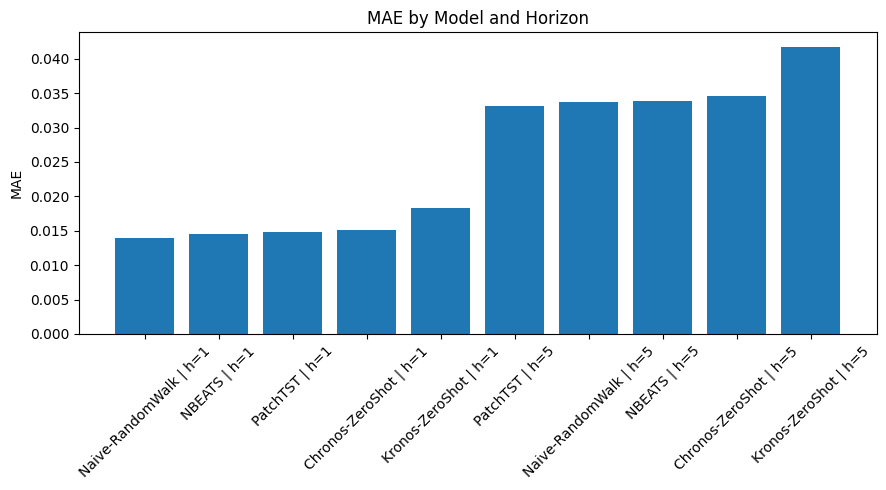

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\mae_by_model.png


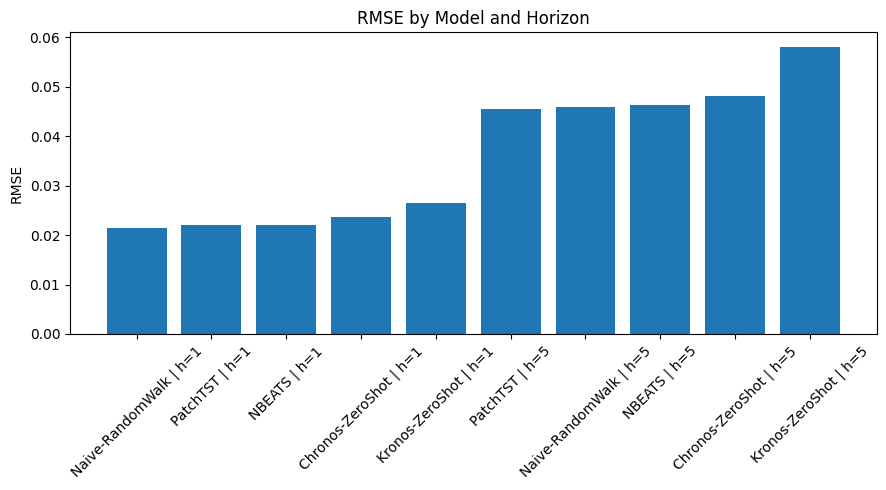

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\rmse_by_model.png


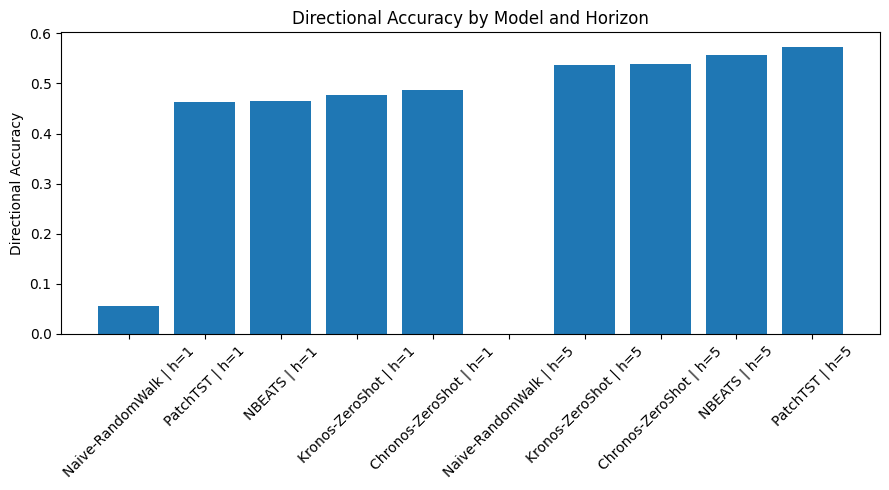

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\directional_accuracy_by_model.png


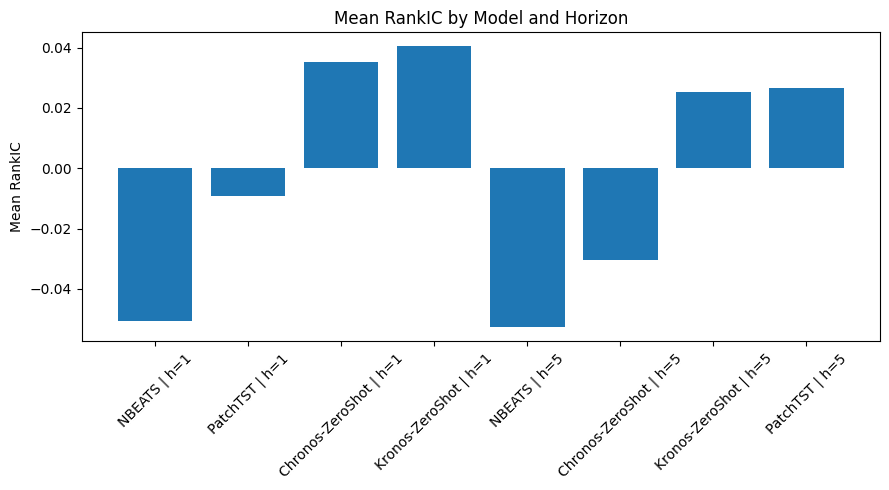

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\rankic_by_model.png


In [27]:
def save_grouped_bar(df: pd.DataFrame, value_col: str, title: str, filename: str, ylabel: str | None = None):
    if df.empty or value_col not in df.columns:
        print(f"Skipping {filename}: no data")
        return

    plot_df = df.copy()
    plot_df["Label"] = plot_df["Model"].astype(str) + " | h=" + plot_df["Horizon"].astype(str)
    plot_df = plot_df.sort_values(["Horizon", value_col])

    fig, ax = plt.subplots(figsize=(max(9, len(plot_df) * 0.7), 5))
    ax.bar(plot_df["Label"], plot_df[value_col])
    ax.set_title(title)
    ax.set_ylabel(ylabel or value_col)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    out = PLOTS_DIR / filename
    plt.savefig(out, dpi=180)
    plt.show()
    print("Saved:", out)

save_grouped_bar(model_summary, "MAE", "MAE by Model and Horizon", "mae_by_model.png", "MAE")
save_grouped_bar(model_summary, "RMSE", "RMSE by Model and Horizon", "rmse_by_model.png", "RMSE")
save_grouped_bar(model_summary, "DirectionalAccuracy", "Directional Accuracy by Model and Horizon", "directional_accuracy_by_model.png", "Directional Accuracy")

if not rank_ic_summary.empty:
    save_grouped_bar(rank_ic_summary.rename(columns={"RankIC_Mean": "MeanRankIC"}), "MeanRankIC", "Mean RankIC by Model and Horizon", "rankic_by_model.png", "Mean RankIC")

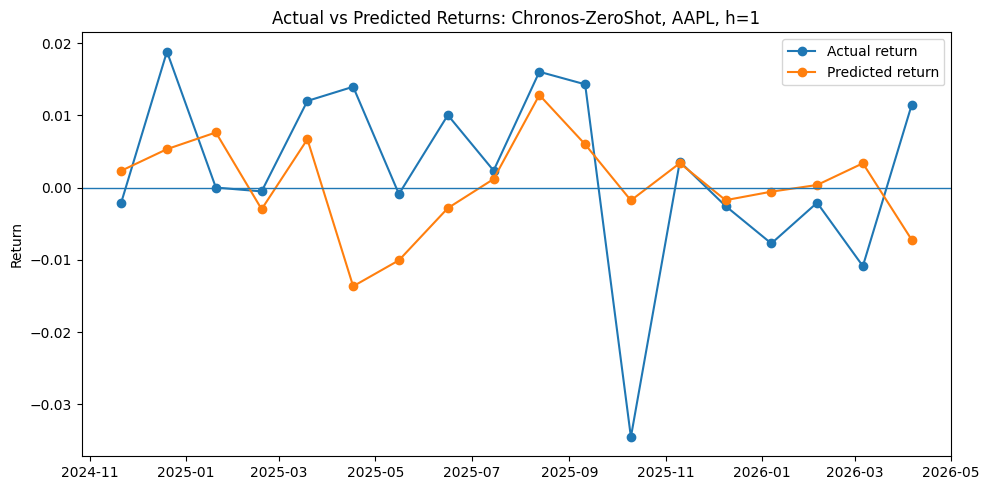

Saved: C:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project\results\new_models\plots\example_actual_vs_predicted.png


In [28]:
# Example actual vs predicted plot for the first available model/ticker/horizon.
example_df = all_predictions.sort_values(["Model", "Ticker", "Horizon", "Date"]).copy()

if not example_df.empty:
    ex_model = example_df["Model"].iloc[0]
    ex_ticker = example_df["Ticker"].iloc[0]
    ex_horizon = example_df["Horizon"].iloc[0]
    g = example_df[(example_df["Model"] == ex_model) & (example_df["Ticker"] == ex_ticker) & (example_df["Horizon"] == ex_horizon)].sort_values("Date")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(g["Date"], g["y_true"], marker="o", label="Actual return")
    ax.plot(g["Date"], g["y_pred"], marker="o", label="Predicted return")
    ax.axhline(0, linewidth=1)
    ax.set_title(f"Actual vs Predicted Returns: {ex_model}, {ex_ticker}, h={ex_horizon}")
    ax.set_ylabel("Return")
    ax.legend()
    plt.tight_layout()
    out = PLOTS_DIR / "example_actual_vs_predicted.png"
    plt.savefig(out, dpi=180)
    plt.show()
    print("Saved:", out)
else:
    print("No predictions available for example plot.")

## Outputs created

This notebook creates or updates:

- `results/new_models/naive_predictions.csv`
- `results/new_models/naive_summary.csv`
- `results/new_models/neural_predictions.csv`
- `results/new_models/chronos_predictions.csv`
- `results/new_models/kronos_predictions.csv`
- `results/new_models/all_predictions.csv`
- `results/new_models/model_summary.csv`
- `results/new_models/rank_ic_by_date.csv`
- `results/new_models/rank_ic_summary.csv`
- `results/new_models/plots/*.png`

Use `model_summary.csv` and `rank_ic_summary.csv` in the final report/presentation.

In [37]:
import pickle
with open(RESULTS_DIR / "emb_cache.pkl", "wb") as f:
    pickle.dump(embedding_predictions, f)
print("Cache saved!")

Cache saved!


In [29]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

In [30]:
from src.config import DATA_PROCESSED_DIR, RESULTS_DIR, PLOTS_DIR
from src.data_utils import load_prepared_panel
from src.new_models import BenchmarkConfig
from src.config import HORIZONS, INPUT_SIZE, TEST_STEP, MAX_TEST_DATES, MAX_STEPS, FREQ, RANDOM_SEED

panel = load_prepared_panel(DATA_PROCESSED_DIR)
panel = panel.sort_values(["Ticker", "Date"]).reset_index(drop=True)

config = BenchmarkConfig(
    horizons=HORIZONS,
    input_size=INPUT_SIZE,
    test_step=TEST_STEP,
    max_test_dates=MAX_TEST_DATES,
    max_steps=MAX_STEPS,
    freq=FREQ,
    random_seed=RANDOM_SEED,
)
print("Panel ready:", panel.shape)

Panel ready: (95400, 11)


In [31]:
from src.embedding_models import run_nbeats_with_embeddings

embedding_predictions = run_nbeats_with_embeddings(
    panel=panel,
    config=config,
    chronos_model_id="amazon/chronos-t5-tiny",
    emb_dims=[8, 16, 32],
)
embedding_predictions.to_csv(RESULTS_DIR / "embedding_predictions.csv", index=False)
print(embedding_predictions["Model"].value_counts())

Chronos encoder loaded from amazon/chronos-t5-tiny on cpu

Horizon 1: 18 cutoff dates
Extracting embeddings for 50 tickers x 18 dates...
  100/900 embeddings extracted
  200/900 embeddings extracted
  300/900 embeddings extracted
  400/900 embeddings extracted
  500/900 embeddings extracted
  600/900 embeddings extracted
  700/900 embeddings extracted
  800/900 embeddings extracted
  900/900 embeddings extracted
Done. 900 embeddings cached.
  Cutoff 1/18: 2024-11-20
  Cutoff 2/18: 2024-12-19
  Cutoff 3/18: 2025-01-17
  Cutoff 4/18: 2025-02-17
  Cutoff 5/18: 2025-03-18
  Cutoff 6/18: 2025-04-16
  Cutoff 7/18: 2025-05-15
  Cutoff 8/18: 2025-06-13
  Cutoff 9/18: 2025-07-14
  Cutoff 10/18: 2025-08-12
  Cutoff 11/18: 2025-09-10
  Cutoff 12/18: 2025-10-09
  Cutoff 13/18: 2025-11-07
  Cutoff 14/18: 2025-12-08
  Cutoff 15/18: 2026-01-06
  Cutoff 16/18: 2026-02-04
  Cutoff 17/18: 2026-03-05
  Cutoff 18/18: 2026-04-03

Horizon 5: 18 cutoff dates
Extracting embeddings for 50 tickers x 18 dates...

In [32]:
print("NBEATS-NoEmb y_pred:")
print(embedding_predictions[embedding_predictions["Model"]=="NBEATS-NoEmb"]["y_pred"].describe())

print("\nNBEATS-Emb-8 y_pred:")
print(embedding_predictions[embedding_predictions["Model"]=="NBEATS-Emb-8"]["y_pred"].describe())

NBEATS-NoEmb y_pred:
count    1800.000000
mean        0.002679
std         0.009024
min        -0.031075
25%        -0.003549
50%         0.002612
75%         0.008496
max         0.036919
Name: y_pred, dtype: float64

NBEATS-Emb-8 y_pred:
count    1800.000000
mean       -0.000856
std         0.009073
min        -0.033469
25%        -0.006210
50%        -0.000965
75%         0.004404
max         0.039763
Name: y_pred, dtype: float64


In [35]:
embedding_predictions.to_csv(RESULTS_DIR / "embedding_predictions.csv", index=False)
print("Saved!")
print(embedding_predictions["Model"].value_counts())

Saved!
Model
NBEATS-NoEmb     1800
NBEATS-Emb-8     1800
NBEATS-Emb-16    1800
NBEATS-Emb-32    1800
Name: count, dtype: int64


if above three cells doesnt work, run last cells

In [33]:
# # Reload embedding module fresh
# import importlib
# import src.embedding_models
# importlib.reload(src.embedding_models)
# from src.embedding_models import run_nbeats_with_embeddings

# embedding_predictions = run_nbeats_with_embeddings(
#     panel=panel,
#     config=config,
#     chronos_model_id="amazon/chronos-t5-tiny",
#     emb_dims=[8, 16, 32],
# )
# embedding_predictions.to_csv(RESULTS_DIR / "embedding_predictions.csv", index=False)
# print(embedding_predictions["Model"].value_counts())

In [34]:
# print("NBEATS-NoEmb y_pred:")
# print(embedding_predictions[embedding_predictions["Model"]=="NBEATS-NoEmb"]["y_pred"].describe())

# print("\nNBEATS-Emb-8 y_pred:")
# print(embedding_predictions[embedding_predictions["Model"]=="NBEATS-Emb-8"]["y_pred"].describe())